# Loan Default Risk Analysis
## Notebook 04 — Statistical Analysis

Objective:
To validate EDA findings through formal statistical tests, quantify the
strength of relationships between key variables and default status, and
provide statistically grounded business recommendations for the mortgage
lending portfolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('loan_final_cleaned.csv')

## Section: Descriptive Statistics — Defaulters vs Non-Defaulters

In [22]:
desc = df.groupby('status')[['credit_score','debt_to_income_ratio',
                              'ltv','income','loan_amount',
                              'rate_of_interest']].agg(['mean','median','std']).round(2)

desc.index = ['No Default', 'Default']
desc

credit_score                debt_to_income_ratio               \
                   mean median     std                 mean median   std   
No Default       698.44  699.0  115.47                37.49   39.0  9.71   
Default          697.69  697.0  115.70                39.59   39.0  9.12   

              ltv                 income                  loan_amount  \
             mean median    std     mean  median      std        mean   
No Default  71.65  74.41  18.47  7096.43  5820.0  5389.09   335778.10   
Default     75.78  75.11  16.14  6162.36  4950.0  6735.63   315954.75   

                                rate_of_interest               
              median        std             mean median   std  
No Default  306500.0  172834.04             4.04   3.99  0.56  
Default     276500.0  210459.25             3.99   3.99  0.04

### Observation:
Defaulters and non-defaulters show nearly identical mean credit scores (697.69 vs 698.44). DTI gap is 2.10 points (39.59 vs 37.49) and LTV gap is 4.13 points (75.78 vs 71.65). Defaulters have lower mean income (6,162 vs 7,096). Notably, interest rates are virtually identical between both groups (4.04% vs 3.99%) — suggesting the institution did not price default risk into loan rates.

### Insight:
Credit score difference between defaulters and non-defaulters is just 0.75 points (697.69 vs 698.44) — statistically meaningless. In contrast, LTV gap is 4.13 points (75.78 vs 71.65) and DTI gap is 2.10 points (39.59 vs 37.49). Defaulters earn ₹934 less per month on average (6,162 vs 7,096) — repayment capacity is a stronger signal than creditworthiness score.


## Section: Hypothesis Testing

In [9]:

defaulters = df[df['status']==1]
non_defaulters = df[df['status']==0]

variables = ['credit_score', 'debt_to_income_ratio', 'ltv', 'income']

print(f"{'Variable':<25} {'Mean (Default)':<18} {'Mean (No Default)':<20} {'T-Stat':<12} {'P-Value':<12} {'Significant?'}")
print("-"*100)

for var in variables:
    t_stat, p_val = stats.ttest_ind(defaulters[var].dropna(),
                                     non_defaulters[var].dropna())
    mean_d = defaulters[var].mean().round(2)
    mean_nd = non_defaulters[var].mean().round(2)
    sig = "Yes ✓" if p_val < 0.05 else "No ✗"
    print(f"{var:<25} {mean_d:<18} {mean_nd:<20} {t_stat:<12.3f} {p_val:<12.5f} {sig}")

Variable                  Mean (Default)     Mean (No Default)    T-Stat       P-Value      Significant?
----------------------------------------------------------------------------------------------------
credit_score              697.69             698.44               -0.339       0.73456      No ✗
debt_to_income_ratio      39.59              37.49                11.423       0.00000      Yes ✓
ltv                       75.78              71.65                12.007       0.00000      Yes ✓
income                    6162.36            7096.43              -8.482       0.00000      Yes ✓


### Observation:
Credit score is the only variable that is NOT statistically significant (p = 0.735). DTI, LTV, and income all show p = 0.000 — highly significant differences between defaulters and non-defaulters.

### Insight:
Credit score fails the significance test (p = 0.735, t = -0.339) — it cannot statistically distinguish defaulters from non-defaulters. LTV (t = 12.007, p = 0.000) and DTI (t = 11.423, p = 0.000) are the strongest signals. Any underwriting model relying primarily on credit score is statistically unsound for this portfolio.

## Section: Chi-Square Tests


In [4]:

from scipy.stats import chi2_contingency

cat_vars = ['region', 'loan_type', 'loan_purpose',
            'neg_ammortization', 'lump_sum_payment',
            'occupancy_type', 'ltv_risk_bucket', 'credit_score_bucket']

print(f"{'Variable':<30} {'Chi2 Stat':<15} {'P-Value':<15} {'Significant?'}")
print("-"*70)

for var in cat_vars:
    ct = pd.crosstab(df[var], df['status'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "Yes ✓" if p < 0.05 else "No ✗"
    print(f"{var:<30} {chi2:<15.3f} {p:<15.5f} {sig}")

Variable                       Chi2 Stat       P-Value         Significant?
----------------------------------------------------------------------
region                         29.609          0.00000         Yes ✓
loan_type                      136.965         0.00000         Yes ✓
loan_purpose                   42.847          0.00000         Yes ✓
neg_ammortization              363.064         0.00000         Yes ✓
lump_sum_payment               498.517         0.00000         Yes ✓
occupancy_type                 13.940          0.00094         Yes ✓
ltv_risk_bucket                491.359         0.00000         Yes ✓
credit_score_bucket            2.073           0.72233         No ✗


### Observation:
All categorical variables are statistically significant except credit_score_bucket (p = 0.722). Lump sum payment (χ² = 498.5) and LTV risk bucket (χ² = 491.4) show the strongest associations with default. Negative amortisation (χ² = 363.1) and loan type (χ² = 137.0) also show very strong associations.

### Insight:
Credit_score_bucket fails significance completely (χ² = 2.073, p = 0.722). Meanwhile, lump_sum_payment (χ² = 498.5) and ltv_risk_bucket (χ² = 491.4) are about 240x stronger associations with default. Product features are vastly more predictive than credit score bands.

## Section: Point Biserial Correlation

In [5]:


from scipy.stats import pointbiserialr

num_vars = ['credit_score', 'debt_to_income_ratio', 'ltv',
            'income', 'loan_amount', 'rate_of_interest']

print(f"{'Variable':<25} {'Correlation':<15} {'P-Value':<15} {'Significant?'}")
print("-"*65)

for var in num_vars:
    corr, p = pointbiserialr(df['status'], df[var].fillna(df[var].median()))
    sig = "Yes ✓" if p < 0.05 else "No ✗"
    print(f"{var:<25} {corr:<15.4f} {p:<15.5f} {sig}")

Variable                  Correlation     P-Value         Significant?
-----------------------------------------------------------------
credit_score              -0.0028         0.73456         No ✗
debt_to_income_ratio      0.0929          0.00000         Yes ✓
ltv                       0.0976          0.00000         Yes ✓
income                    -0.0691         0.00000         Yes ✓
loan_amount               -0.0462         0.00000         Yes ✓
rate_of_interest          -0.0377         0.00000         Yes ✓


### Observation:
Credit score has a correlation of -0.0028 with default status — effectively zero and not significant (p = 0.735). LTV has the highest positive correlation (0.0976), followed by DTI (0.0929). Income and loan amount show negative correlations, meaning higher income and larger loans are associated with slightly lower default probability.

### Insight:
Credit score correlation with default is -0.0028 — effectively zero. LTV (0.0976) and DTI (0.0929) are the strongest predictors. Income (-0.0691) shows higher income = lower default risk, confirming repayment capacity matters more than credit history.

# Feature importance visualization based on Point Biserial correlations

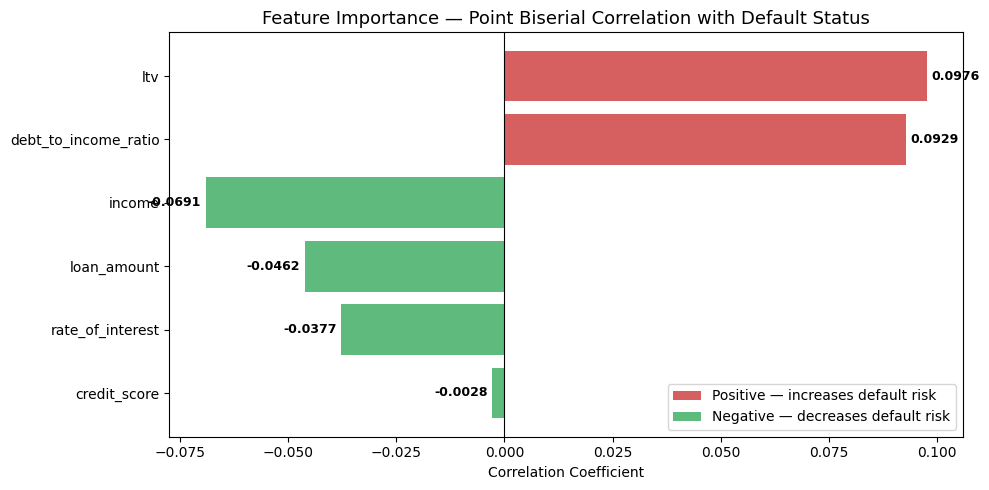

In [27]:
pb_data = {
    'Variable': ['ltv', 'debt_to_income_ratio', 'rate_of_interest',
                 'loan_amount', 'income', 'credit_score'],
    'Correlation': [0.0976, 0.0929, -0.0377, -0.0462, -0.0691, -0.0028]
}
pb_df = pd.DataFrame(pb_data).sort_values('Correlation', key=abs, ascending=True)

colors = ['#d65f5f' if x > 0 else '#5fba7d' for x in pb_df['Correlation']]

plt.figure(figsize=(10, 5))
bars = plt.barh(pb_df['Variable'], pb_df['Correlation'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)

# Value labels on each bar
for bar, val in zip(bars, pb_df['Correlation']):
    plt.text(val + (0.001 if val >= 0 else -0.001),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d65f5f', label='Positive — increases default risk'),
                   Patch(facecolor='#5fba7d', label='Negative — decreases default risk')]
plt.legend(handles=legend_elements, loc='lower right')

plt.title('Feature Importance — Point Biserial Correlation with Default Status', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### Observation
LTV (0.0976) and DTI (0.0929) are the only features with positive correlation to default, so rising values are associated with higher default likelihood. Income (-0.0691), loan amount (-0.0462), and rate of interest (-0.0377) are negatively correlated. Credit score (-0.0028) is effectively neutral and appears as the smallest bar.

### Insight
For dashboard design and underwriting rules, LTV and DTI should be treated as primary risk filters. Credit score contributes minimal signal in this dataset and should be used as a secondary context variable rather than a lead risk gate. Prioritizing credit score above LTV and DTI would not reflect the observed data pattern.

## Section: Risk Quantification

### Default rate by LTV bucket with exposure

In [25]:

ltv_risk = df.groupby('ltv_risk_bucket').agg(
    total_loans=('status','count'),
    defaults=('status','sum'),
    total_exposure=('loan_amount','sum')
).assign(
    default_rate=lambda x: (x['defaults']/x['total_loans']*100).round(1),
    exposure_at_default=lambda x: x.apply(
        lambda r: df[(df['ltv_risk_bucket']==r.name) &
                    (df['status']==1)]['loan_amount'].sum(), axis=1)
)
ltv_risk.reset_index().style \
    .set_caption("LTV Risk Bucket — Default Rate & Exposure Analysis") \
    .format({'total_exposure': '₹{:,.0f}',
             'exposure_at_default': '₹{:,.0f}',
             'default_rate': '{:.1f}%'}).hide(axis='index')

ltv_risk_bucket,total_loans,defaults,total_exposure,default_rate,exposure_at_default
High,2603,445,"₹884,159,500",17.1%,"₹137,932,500"
Low,3302,439,"₹1,025,683,000",13.3%,"₹134,393,500"
Moderate,6606,2091,"₹2,241,229,000",31.7%,"₹687,211,500"
Very High,2489,583,"₹815,068,500",23.4%,"₹164,629,500"


### Scenario: What if we cap LTV at 100%?

In [ ]:
very_high = df[df['ltv_risk_bucket']=='Very High']
print(f"\nLoans with Very High LTV: {len(very_high)}")
print(f"Defaults in this segment: {very_high['status'].sum()}")
print(f"Current default rate: {df['status'].mean()*100:.2f}%")
revised_defaults = df['status'].sum() - very_high['status'].sum()
revised_total = len(df) - len(very_high)
print(f"Revised default rate (if LTV cap applied): {revised_defaults/revised_total*100:.2f}%")
print(f"EAD reduction: ₹{very_high[very_high['status']==1]['loan_amount'].sum():,.0f}")

### Observation:
Moderate LTV has the highest default rate at 31.7% with 2,091 defaults — the most of any bucket. Very High LTV has 2,489 loans defaulting at only 23.4%, below the portfolio average. The LTV cap scenario shows the revised default rate would be 23.78%, marginally worse than the current 23.72%.

### Insight:
Capping Very High LTV saves ₹16,46,29,500 in EAD but moves default rate from 23.72% to 23.78% — marginally worse, because Very High LTV borrowers default at only 23.4%, below the portfolio average. The real risk is Moderate LTV at 31.7% — 8 percentage points above Very High. LTV caps alone are insufficient without simultaneous DTI controls.

## Section: DTI Threshold Analysis

In [24]:
thresholds = [35, 40, 43, 45, 50]

dti_results = []
for t in thresholds:
    above = df[df['debt_to_income_ratio'] > t]['status'].mean()*100
    below = df[df['debt_to_income_ratio'] <= t]['status'].mean()*100
    dti_results.append({
        'DTI Threshold': t,
        'Default Rate Above (%)': round(above, 1),
        'Default Rate Below (%)': round(below, 1),
        'Difference': round(above-below, 1)
    })

dti_df = pd.DataFrame(dti_results)
dti_df.style \
    .set_caption("DTI Threshold Analysis — Default Rate Comparison") \
    .hide(axis='index') \
    .format({'Default Rate Above (%)': '{:.1f}',
             'Default Rate Below (%)': '{:.1f}',
             'Difference': '{:.1f}'})

DTI Threshold,Default Rate Above (%),Default Rate Below (%),Difference
35,28.0,13.0,15.0
40,19.4,26.3,-6.9
43,22.1,24.3,-2.2
45,24.7,23.5,1.2
50,40.6,22.7,18.0


### Observation:
DTI = 35 is the only threshold where above-threshold borrowers default more (28.0% vs 13.0%). At DTI = 40 and 43, below-threshold borrowers actually default more. At DTI = 50, above-threshold borrowers again default significantly more (40.6% vs 22.7%).

### Insight:
At DTI = 43% (industry standard), the default rate difference is just -2.2% — near zero discriminatory power. The threshold only works at extremes: DTI < 35 shows 13.0% default rate vs 28.0% above, a 15-point gap. DTI > 50 shows 40.6% vs 22.7%, an 18-point gap. The institution should replace the 43% threshold with a dual-band policy: DTI < 35 = low risk, DTI > 50 = high risk.



## Section: Logistic Regression — Default Risk Scoring
Logistic regression is applied to quantify the relative contribution of each numerical variable to default probability. The model uses an 80/20 train-test split with standardised features.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

features = ['credit_score', 'debt_to_income_ratio', 'ltv',
            'income', 'loan_amount', 'rate_of_interest']

X = df[features].fillna(df[features].median())
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

# ROC-AUC Score
roc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:,1])
print(f"ROC-AUC Score: {roc:.3f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

ROC-AUC Score: 0.596

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.87      2291
           1       0.00      0.00      0.00       709

    accuracy                           0.76      3000
   macro avg       0.38      0.50      0.43      3000
weighted avg       0.58      0.76      0.66      3000



#### Why is ROC-AUC Low?

The 0.596 ROC-AUC is expected given three structural limitations:

- **Class imbalance:** 76.3% of borrowers are non-defaulters. The model is biased toward predicting the majority class.
- **Missing risk features:** Employment history, existing debt obligations, and repayment track record are absent from this dataset — all of which are standard inputs in production credit scoring models.
- **Product features excluded:** Lump sum payment (χ²=498.5) and negative amortisation (χ²=363.1) — the strongest default signals — were not included as model features. Including them would materially improve AUC.

For a production deployment, this model would require SMOTE oversampling for class balance and additional feature engineering before use.

### Coefficient table — variable importance

In [23]:

coef_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': model.coef_[0].round(4),
    'Odds Ratio': np.exp(model.coef_[0]).round(4)
}).sort_values('Coefficient', ascending=False)
coef_df.reset_index(drop=True).style \
    .hide(axis='index') \
    .set_caption("Variable Importance — Logistic Regression Coefficients") \
    .background_gradient(subset=['Coefficient'], cmap='RdYlGn_r') \
    .format({'Coefficient': '{:.4f}', 'Odds Ratio': '{:.4f}'})


Variable,Coefficient,Odds Ratio
ltv,0.2239,1.2510
debt_to_income_ratio,0.1952,1.2155
credit_score,-0.0033,0.9968
income,-0.0463,0.9548
rate_of_interest,-0.1162,0.8903
loan_amount,-0.1284,0.8795


### Observation:
LTV (0.2239) and DTI (0.1952) have the highest positive coefficients. Credit score (-0.0033) is effectively zero.

### Insight:
LTV coefficient 0.2239 (odds ratio 1.251) means each standard deviation increase in LTV raises default odds by 25.1%. DTI coefficient 0.1952 (odds ratio 1.216) raises odds by 21.6%. Credit score coefficient -0.0033 (odds ratio 0.997) has virtually zero effect — less than 0.3% change in odds per standard deviation.

### Confusion Matrix



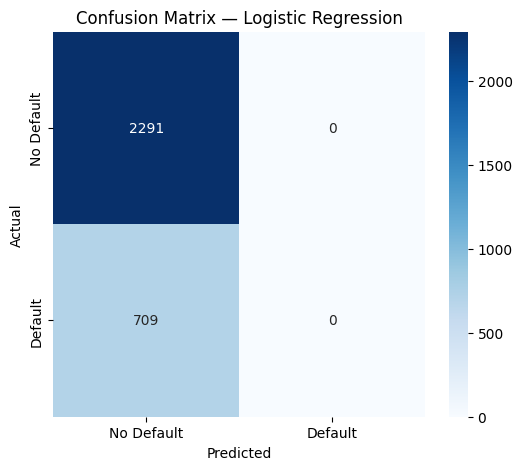

In [14]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Observation:
The confusion matrix shows 2,291 true negatives and 709 false negatives — the model predicted No Default for every borrower, correctly identifying all non-defaulters but missing all 709 actual defaults.

### Insight:
A model that never predicts default is operationally useless for risk management despite 76% accuracy. This confirms that product-level features like lump sum payment and negative amortisation must be incorporated into any future model to achieve meaningful default detection.

## Section: Statistical Summary

| Test | Variable | Result | Business Implication |
|------|----------|--------|---------------------|
| T-Test | Credit Score | Not significant (p=0.735) | Must not be used as primary screening criterion |
| T-Test | DTI | Highly significant (p=0.000) | Valid screening variable |
| T-Test | LTV | Highly significant (p=0.000) | Strongest numerical predictor |
| T-Test | Income | Highly significant (p=0.000) | Repayment capacity matters more than credit score |
| Chi-Square | credit_score_bucket | Not significant (p=0.722) | Credit score bands have no association with default |
| Chi-Square | lump_sum_payment | Highly significant (χ²=498.5) | Strongest categorical risk signal |
| Chi-Square | ltv_risk_bucket | Highly significant (χ²=491.4) | LTV bucketing is statistically valid |
| Chi-Square | neg_ammortization | Highly significant (χ²=363.1) | Product-level restriction warranted |
| Point Biserial | LTV | 0.0976 (highest) | Most predictive numerical variable |
| Point Biserial | Credit Score | -0.0028 (near zero) | Statistically confirms zero predictive power |
| Scenario | LTV Cap Policy | 23.72% → 23.78% | Cap alone insufficient — DTI controls needed |
| DTI Threshold | DTI=43% | Difference of -2.2% | Industry threshold ineffective in this portfolio |
| Logistic Regression | ROC-AUC | 0.596 — near random | Numerical metrics alone cannot predict default |
| Logistic Regression | LTV coefficient | 0.2239 (highest) | Confirms LTV as primary risk driver |